In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


# Construimos el kernel tipo Radial Basis Function (RBF) para calcular la similitud entre dos puntos
def rbf_kernel(x1, x2, gamma):
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)

def plot_combined_contour(X_class1, X_class2, titulo, gamma):
    h = 0.02
    x_min, x_max = min(X_class1[:, 0].min(), X_class2[:, 0].min()) - 1, max(X_class1[:, 0].max(), X_class2[:, 0].max()) + 1
    y_min, y_max = min(X_class1[:, 1].min(), X_class2[:, 1].min()) - 1, max(X_class1[:, 1].max(), X_class2[:, 1].max()) + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z1 = np.zeros(xx.shape)
    Z2 = np.zeros(xx.shape)

    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            x_point = np.array([xx[i, j], yy[i, j]])
            Z1[i, j] = np.sum([rbf_kernel(x_point, x, gamma) for x in X_class1])
            Z2[i, j] = np.sum([rbf_kernel(x_point, x, gamma) for x in X_class2])

    # Cálculo del mapa total de diferencias
    Z_total = Z1 - Z2

    plt.figure(figsize=(8, 6))
    
    # Rellenar el fondo con color sólido
    plt.contourf(xx, yy, Z_total, levels=1, cmap=cm.plasma, alpha=0.4)

    # Línea negra para marcar el valle entre clases
    plt.contour(xx, yy, Z_total, levels=[0], colors="black", linewidths=2)

    plt.scatter(X_class1[:, 0], X_class1[:, 1], color="red", edgecolors='k', s=100, label="Clase 1")
    plt.scatter(X_class2[:, 0], X_class2[:, 1], color="purple", edgecolors='k', s=100, label="Clase 2")
    
    plt.title(titulo)
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.legend()
    plt.show()

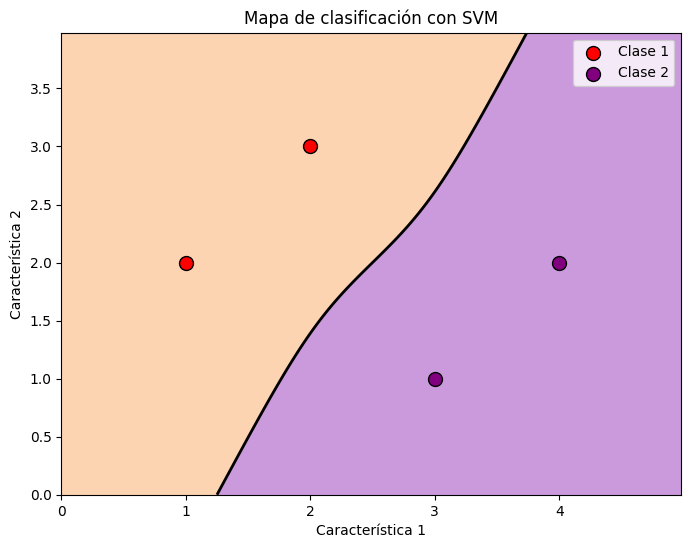

In [13]:
gamma = 1.0
X = np.array([[1, 2], [2, 3], [3, 1], [4, 2]])
Y = np.array([1, 1, -1, -1])

X_class1 = X[Y == 1][:2]
X_class2 = X[Y == -1][:2]

plot_combined_contour(X_class1, X_class2, "Mapa de clasificación con SVM", gamma)

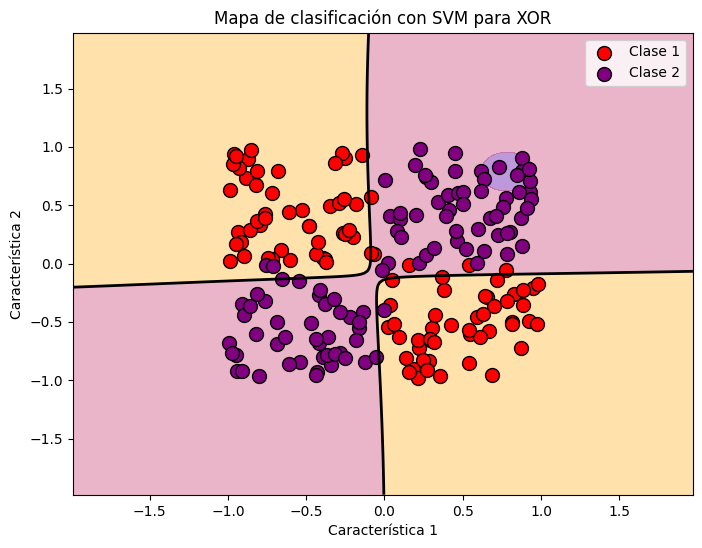

In [ ]:
# ahora con valores que responden a un XOR 

np.random.seed(42)
X2 = np.random.rand(200, 2) * 2 - 1  # valores a rango [-1, 1]
Y2 = np.logical_xor(X2[:, 0] > 0, X2[:, 1] > 0)
Y2 = np.where(Y2, 1, -1)

X_class1 = X2[Y2 == 1]
X_class2 = X2[Y2 == -1]
plot_combined_contour(X_class1, X_class2, "Mapa de clasificación con SVM para XOR", gamma)